# Import Library

In [ ]:
import os
import time
import shap
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score, f1_score, accuracy_score, precision_recall_curve, auc

# Shared Preprocessing Code

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset loaded successfully.
Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  fl

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Target distribution:


,count
Class,
0,284315
1,492


Fraud ratio: 0.1727%


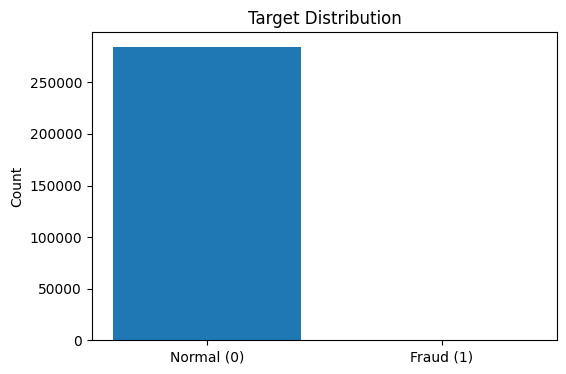

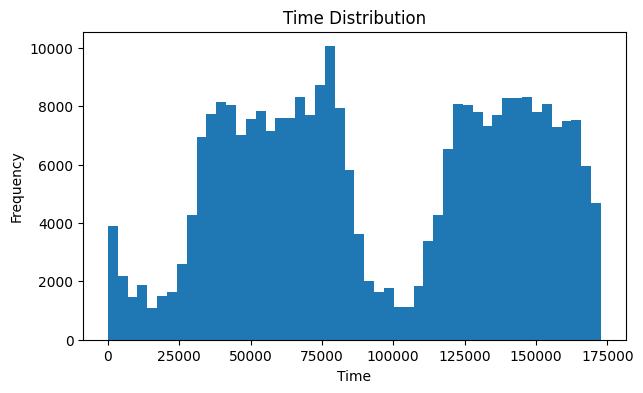

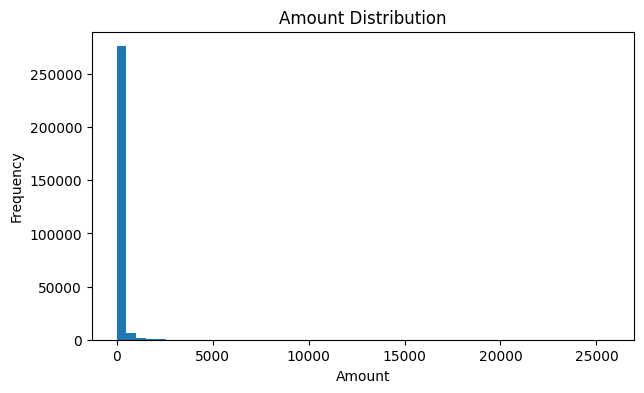

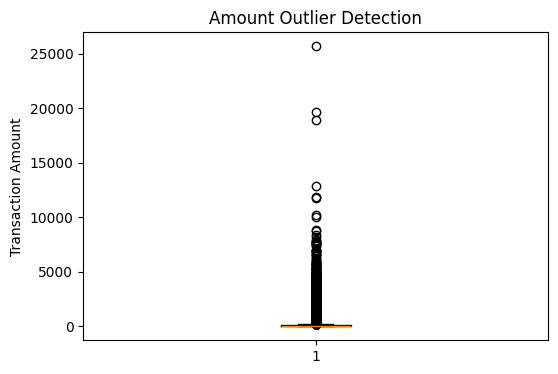

Feature matrix shape: (284807, 30)
Target shape: (284807,)
Preprocessing completed successfully.
Train shape: (256326, 30)
Test shape: (28481, 30)

Train distribution:
Class
0    0.998272
1    0.001728
Name: proportion, dtype: float64

Test distribution:
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64

Processed files saved successfully.
The same preprocessing pipeline can be used across all project models.


In [ ]:
# 1. Download and load dataset
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(os.path.join(path, "creditcard.csv"))

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)
display(df.head())


# 2. Basic inspection
print("Dataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nStatistical summary:")
display(df.describe())

# 3. Target distribution
print("Target distribution:")
display(df["Class"].value_counts())

fraud_ratio = df["Class"].mean() * 100
print(f"Fraud ratio: {fraud_ratio:.4f}%")

plt.figure(figsize=(6, 4))
plt.bar(["Normal (0)", "Fraud (1)"], df["Class"].value_counts().sort_index().values)
plt.title("Target Distribution")
plt.ylabel("Count")
plt.show()

# 4. Simple EDA
plt.figure(figsize=(7, 4))
plt.hist(df["Time"], bins=50)
plt.title("Time Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(df["Amount"], bins=50)
plt.title("Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6, 4))
plt.boxplot(df["Amount"])
plt.title("Amount Outlier Detection")
plt.ylabel("Transaction Amount")
plt.show()

# 5. Separate features and target
X = df.drop("Class", axis=1).copy()
y = df["Class"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

# 6. Scale only Time and Amount
#    The PCA features (V1-V28) are already transformed
scaler = StandardScaler()
X[["Time", "Amount"]] = scaler.fit_transform(X[["Time", "Amount"]])

print("Preprocessing completed successfully.")

# 7. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=7,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))


# 8. Save split files if needed
X_train.to_csv("X_train_processed.csv", index=False)
X_test.to_csv("X_test_processed.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("\nProcessed files saved successfully.")
print("The same preprocessing pipeline can be used across all project models.")

## Filter training data to have only normal transaction for traing the model on normal transactions

In [ ]:
# 1. Filter training data to include only normal transactions
X_train_normal = X_train[y_train == 0]

print("Filtered training data shape:", X_train_normal.shape)
print(f"The difference between X_train and X_train_normal is {X_train.shape[0] - X_train_normal.shape[0]} samples.")

Filtered training data shape: (255883, 30)
The difference between X_train and X_train_normal is 443 samples.


#Hyperparameter Tuning


In [ ]:
# Define parameters to test
nus = [0.01, 0.05]
gammas = ['scale', 'auto', 0.1, 0.01]

best_f1 = -1
best_params = {}
results = []

print(f"Starting tuning on {len(nus) * len(gammas)} combinations...\n")

for nu in nus:
    for gamma in gammas:
        start = time.time()

        # Initialize and fit
        model = OneClassSVM(kernel='rbf', nu=nu, gamma=gamma)
        model.fit(X_train_normal)

        # Predict and evaluate
        y_pred_raw = model.predict(X_test)
        y_pred_curr = np.where(y_pred_raw == 1, 0, 1)
        current_f1 = f1_score(y_test, y_pred_curr)

        duration = time.time() - start
        results.append({'nu': nu, 'gamma': gamma, 'f1': current_f1})

        print(f"Tested: nu={nu}, gamma={gamma} | F1: {current_f1:.4f} | Time: {duration:.2f}s")

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_params = {'nu': nu, 'gamma': gamma}
            best_model_manual = model

print(f"\nBest Manual Params: {best_params}")
print(f"Best Manual F1 Score: {best_f1:.4f}")

Starting tuning on 8 combinations...

Tested: nu=0.01, gamma=scale | F1: 0.2171 | Time: 262.32s
Tested: nu=0.01, gamma=auto | F1: 0.2111 | Time: 246.88s
Tested: nu=0.01, gamma=0.1 | F1: 0.0709 | Time: 1271.30s
Tested: nu=0.01, gamma=0.01 | F1: 0.2265 | Time: 1549.21s
Tested: nu=0.05, gamma=scale | F1: 0.0583 | Time: 897.58s
Tested: nu=0.05, gamma=auto | F1: 0.0581 | Time: 903.20s
Tested: nu=0.05, gamma=0.1 | F1: 0.0554 | Time: 1320.33s
Tested: nu=0.05, gamma=0.01 | F1: 0.0604 | Time: 852.28s

Best Manual Params: {'nu': 0.01, 'gamma': 0.01}
Best Manual F1 Score: 0.2265


The time for the Hyperparameter Tuning is 7303.1 sec -> 121.7 min -> ~ 2 hrs.

In [ ]:
best_oc_svm = best_model_manual
y_pred_best_raw = best_oc_svm.predict(X_test)
y_pred_best = np.where(y_pred_best_raw == 1, 0, 1)

print("Final Model Evaluation (Optimized):")
print(classification_report(y_test, y_pred_best, target_names=['Normal', 'Fraud']))

cm_best = confusion_matrix(y_test, y_pred_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['Normal', 'Fraud'])
disp_best.plot(cmap='Greens')
plt.title('Optimized One-Class SVM Confusion Matrix')
plt.show()

# One-Class SVM Implementation


In [ ]:
# Initialize One-Class SVM
oc_svm = OneClassSVM(kernel='rbf', gamma=0.01, nu=0.01)

# Fit the model and measure time
print("Training One-Class SVM on normal transactions...")
start_time = time.time()
oc_svm.fit(X_train_normal)
end_time = time.time()

train_duration = end_time - start_time
print(f"Training completed in {train_duration/60:.2f} minutes.")

Training One-Class SVM on normal transactions...
Training completed in 29.40 minutes.


In [ ]:
# Predict on the test set
y_pred_raw = oc_svm.predict(X_test)

# Convert predictions to match original labels (0 for normal, 1 for fraud)
y_pred = np.where(y_pred_raw == 1, 0, 1)


Evaluation on Test Set:
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     28432
       Fraud       0.13      0.84      0.23        49

    accuracy                           0.99     28481
   macro avg       0.57      0.91      0.61     28481
weighted avg       1.00      0.99      0.99     28481

Confusion Matrix:


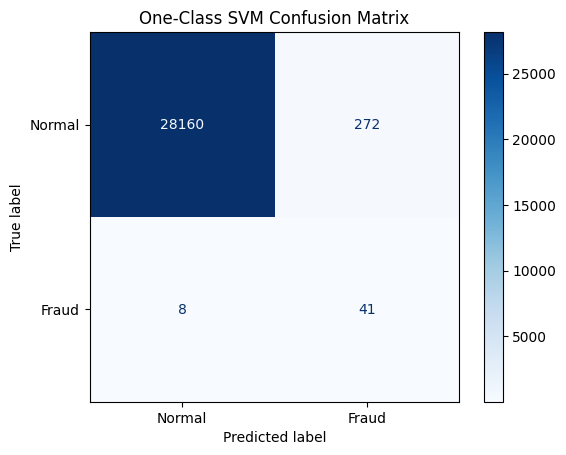

Area Under Precision-Recall Curve (AUC-PR):


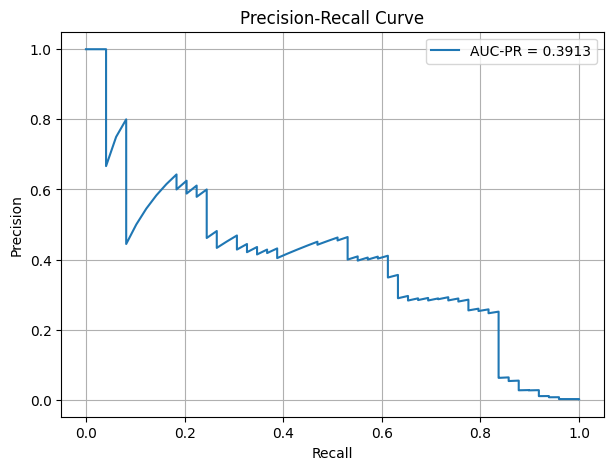

In [ ]:
print("\nEvaluation on Test Set:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

# Plot Confusion Matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('One-Class SVM Confusion Matrix')
plt.show()

# Plot Precision-Recall Curve
print('Area Under Precision-Recall Curve (AUC-PR):')
y_scores = oc_svm.decision_function(X_test)
# Convert scores so that lower distance (more anomalous) has higher fraud probability
# Note: predict() returns -1 for outlier, 1 for inlier.
precision, recall, thresholds = precision_recall_curve(y_test, -y_scores)
aucrp = auc(recall, precision)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f'AUC-PR = {aucrp:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [ ]:
accuracy = accuracy_score(y_test, y_pred)*100
precision = precision_score(y_test, y_pred)*100
recall = recall_score(y_test, y_pred)*100
f1 = f1_score(y_test, y_pred)*100

print(f"Accuracy: {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall: {recall:.2f}%")
print(f"F1 Score: {f1:.2f}%")

Accuracy: 99.02%
Precision: 13.10%
Recall: 83.67%
F1 Score: 22.65%


  0%|          | 0/2 [00:00<?, ?it/s]

Explaining a flagged Fraud transaction:


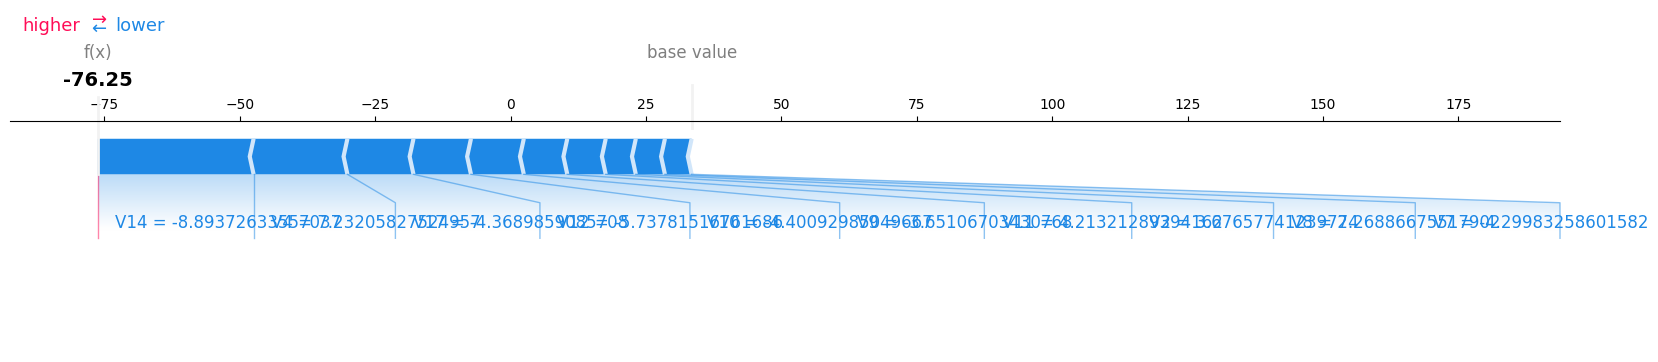


SHAP Summary Plot:


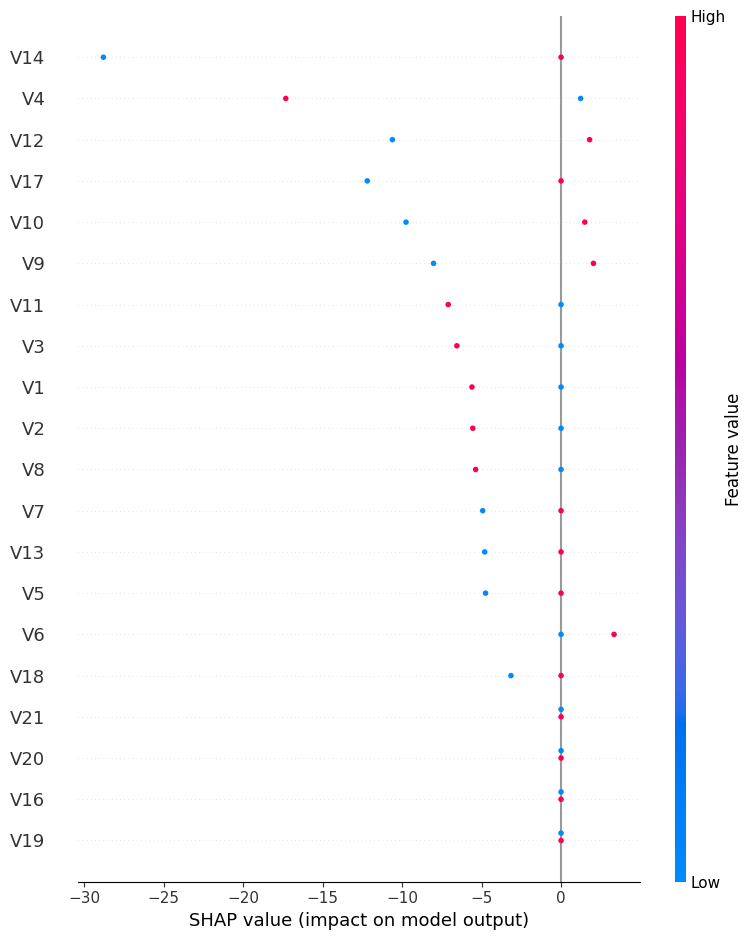

In [ ]:
# Select a few samples to explain (e.g., some true positives and true negatives)
# Find indices where the model correctly identified fraud
fraud_indices = np.where((y_test == 1) & (y_pred == 1))[0]
normal_indices = np.where((y_test == 0) & (y_pred == 0))[0]

# Pick one of each for explanation
idx_to_explain = [fraud_indices[0], normal_indices[0]]
X_explain = X_test.iloc[idx_to_explain]

# Use SHAP KernelExplainer
# Note: We use a small background dataset to speed up computation
background = shap.sample(X_train_normal, 50)
explainer = shap.KernelExplainer(oc_svm.decision_function, background)
shap_values = explainer.shap_values(X_explain)

# Visualize the first prediction (Fraud transaction)
print("Explaining a flagged Fraud transaction:")
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_explain.iloc[0],
    matplotlib=True
)

# 4. Summary plot for the explained samples
print("\nSHAP Summary Plot:")
shap.summary_plot(shap_values, X_explain)

### Global Feature Importance Analysis

Generating Global Feature Importance Plot...


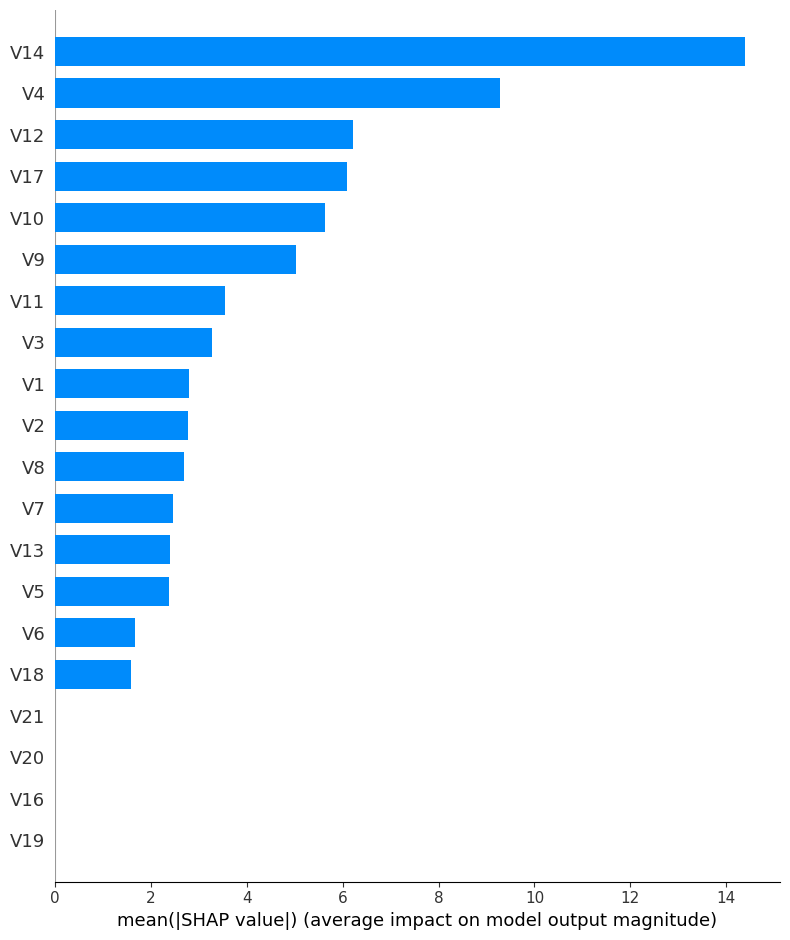

In [ ]:
# Calculate mean absolute SHAP values to represent global importance
print("Generating Global Feature Importance Plot...")
shap.summary_plot(shap_values, X_explain, plot_type="bar")

## Inference Time


In [ ]:
import sys

# Measure inference time
print("Measuring inference time...")
start_time = time.time()
y_pred_inference = oc_svm.predict(X_test)
end_time = time.time()
inference_duration = end_time - start_time
print(f"Inference on {X_test.shape[0]} samples took {inference_duration:.4f} seconds ({inference_duration / X_test.shape[0] * 1000:.4f} ms per sample).")

Measuring inference time...
Inference on 28481 samples took 7.4749 seconds (0.2625 ms per sample).
